In [1]:
from time import time

import numpy as np

from quantum_simulation.configs import jpc_config_dudas, quantum_parameters
from quantum_simulation.jpc_chip import JPCChip

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = \sqrt{\kappa_a}  \left( \epsilon_a^* a + \epsilon_a a^\dagger \right) + \sqrt{\kappa_b}  \left( \epsilon_b^* b + \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \left[ \sqrt{\kappa_a}\; a \;, \;  \sqrt{\kappa_b}\; b \; , \; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) \right]$$


In [2]:
X = np.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7])

chip = JPCChip(jpc_config_dudas)
quantum_parameters = quantum_parameters
jpc_config_dudas.summary()
quantum_parameters.summary()

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)
QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0,
    encoding=('g_sq',),
    f_encoding=<function QuantumParameters.<lambda> at 0x00000184673FBF60>
)


In [3]:
t1 = time()
A_epsilon = chip.run_simulation(X, [quantum_parameters])
print(time() - t1)
#c-profile

|██████████| 100.0% ◆ elapsed 9.09s ◆ remaining 0.00ms  


17.093944787979126


C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


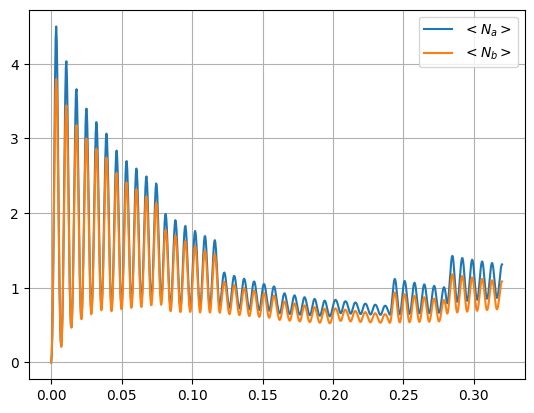

In [4]:
l = A_epsilon[0].photon_distribution.Plot_Mean_Photon_Number()

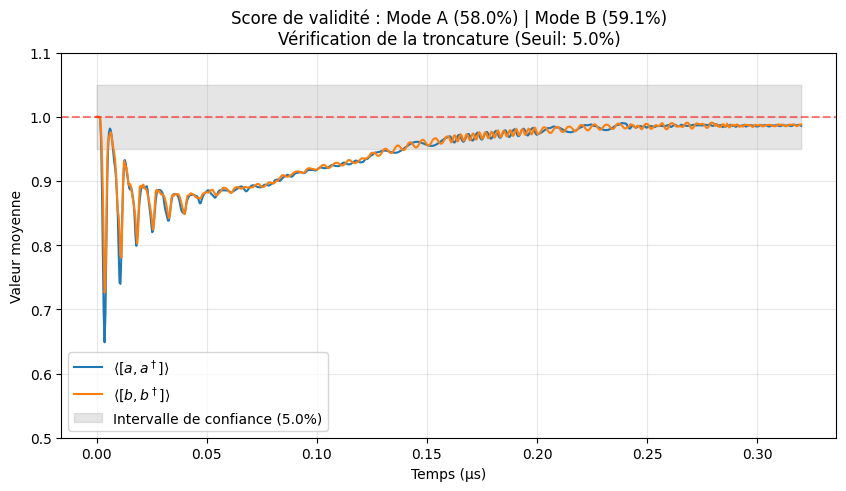

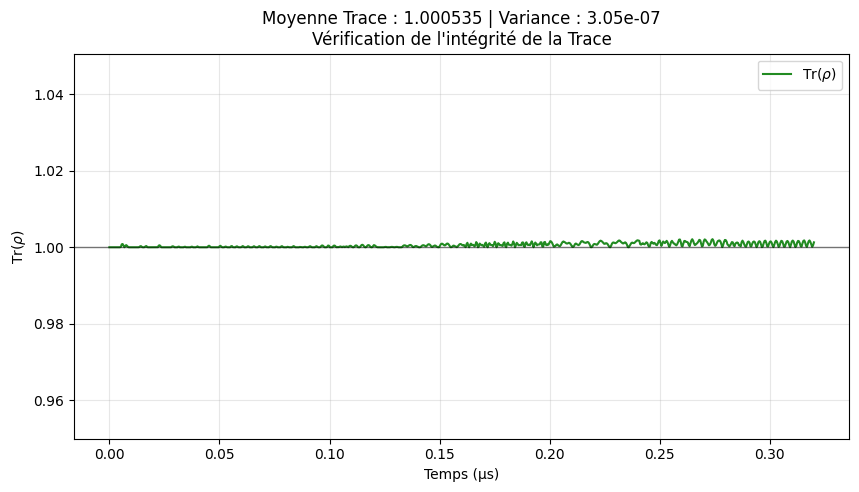

In [5]:
A_epsilon[0].plot_commutator_verification()
A_epsilon[0].plot_trace_integrity()

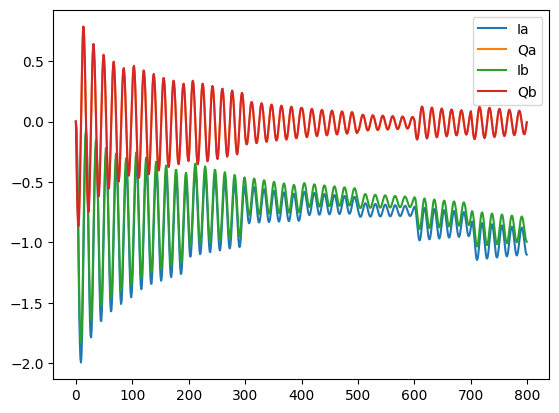

In [6]:
A_epsilon[0].quadratures.plot()

In [7]:
import numpy as np
import sys

# Pour afficher TOUT le tableau sans troncature
np.set_printoptions(threshold=sys.maxsize)

# Pour afficher un nombre précis de chiffres après la virgule (ex: 4)
np.set_printoptions(precision=4, suppress=True)

print(A_epsilon[0].quadratures.L_Ia.reshape(10, -1))

[[ 0.     -0.0666 -0.2576 -0.5485 -0.9022 -1.2696 -1.5929 -1.8285 -1.9618
  -1.9942 -1.9301 -1.7714 -1.5244 -1.2108 -0.8716 -0.5548 -0.3021 -0.1424
  -0.0926 -0.1591 -0.3329 -0.5888 -0.889  -1.1927 -1.4634 -1.6639 -1.7712
  -1.786  -1.7152 -1.5639 -1.3441 -1.0786 -0.7998 -0.5447 -0.3459 -0.2257
  -0.1977 -0.2645 -0.4161 -0.6329 -0.8863 -1.1451 -1.3795 -1.5556 -1.6476
  -1.6516 -1.576  -1.431  -1.231  -0.9973 -0.7583 -0.5447 -0.3822 -0.2899
  -0.2789 -0.3499 -0.494  -0.6937 -0.9233 -1.1526 -1.3531 -1.4991 -1.5712
  -1.563  -1.4806 -1.3369 -1.1481 -0.9351 -0.7234 -0.5401 -0.408  -0.3425
  -0.3504 -0.4305 -0.5733 -0.7606 -0.9685 -1.1702 -1.3407 -1.4589]
 [-1.5097 -1.4879 -1.3992 -1.2571 -1.0788 -0.8846 -0.6973 -0.5402 -0.4332
  -0.3892 -0.4127 -0.5002 -0.6407 -0.8166 -1.0055 -1.1836 -1.3285 -1.4226
  -1.4547 -1.4214 -1.3283 -1.1908 -1.0161 -0.8235 -0.6368 -0.4806 -0.3749
  -0.3322 -0.3571 -0.446  -0.5875 -0.7631 -0.9508 -1.1269 -1.2694 -1.36
  -1.3876 -1.3493 -1.2512 -1.1072 -0.9356 -0.75

In [8]:
%matplotlib widget

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
A_epsilon[0].photon_distribution.plot_joint_proba(use_log=True)

In [ ]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='a')

In [ ]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='b', use_log=True)

In [ ]:
A_epsilon[0].photon_distribution.P_b[-1]

In [ ]:
import sympy as sp
from IPython.display import display, Math

# Variables
k1, k2 = sp.symbols('kappa1 kappa2', real=True)
g, gs = sp.symbols('g gs')

# Modules au carré
g2 = sp.Abs(g) ** 2
gs2 = sp.Abs(gs) ** 2

# Coefficients
p = g2 + gs2 + (k1 ** 2 + k2 ** 2) / 4
q = (-g2 + gs2 - k1 * k2 / 4) ** 2

# lambda^2
x_plus = (-p + sp.sqrt(p ** 2 - 4 * q)) / 2
x_minus = (-p - sp.sqrt(p ** 2 - 4 * q)) / 2

# valeurs propres
lambdas = [
    sp.sqrt(x_plus), -sp.sqrt(x_plus),
    sp.sqrt(x_minus), -sp.sqrt(x_minus)
]

# Affichage LaTeX
for lam in lambdas:
    display(Math(sp.latex(sp.simplify(lam))))

In [ ]:
eigs

In [ ]:
sp.latex(eigs)